# PINN for the Harmonic Oscillator

Consider the simple harmonic oscillator:
\begin{equation}
\begin{cases}
    \ddot{x}(t) + \omega^2x(t) = 0,\\
    x(t=0) = 1,\\
    \dot{x}(t=0) = 0,
\end{cases}
\end{equation}
on $t ∈ [0, T]$ with $\omega = 2\pi$ (i.e. $P=1$) and $T = 2$ (two full oscillations). The exact solution is
simply
$x(t) = \mathrm{cos}(\omega t)$.

**Loss Function**

The total loss has two terms.

*ODE residual loss*. 

Sample $N_r$ collocation points $\{t_{k}\}^{N_r}_{k=1}$ uniformly in $[0, T]$. At each point evaluate the ODE residual using AD:

\begin{equation}
    \mathcal{L}_{r} = \frac{1}{N_r}\sum_{k=1}^{Nr}{\biggl[\ddot{\hat{x}}(t_k)+\omega^2\hat{x}(t_k)\biggr]^2}.
\end{equation}

Both $\dot{\hat{x}}(t_k)$ and $\ddot{\hat{x}}(t_k)$ are computed by applying AD twice to the network’s forward pass with respect to t.

*Initial condition loss*. 

Enforce both $x(0) = 1$ and $\dot{\hat{x}}(0) = 0$:

\begin{equation}
    \mathcal{L}_0 = \biggl(\hat{x}(0)-1\biggr)^2+\biggl(\dot{\hat{x}}(0)-0\biggr)^2
\end{equation}

The total loss is:
$\mathcal{L} = \mathcal{L}_r + \lambda_0 \mathcal{L}_0$.
A good starting value is $\lambda_0 = 10$ to ensure the initial conditions are satisfied tightly before the ODE residual pulls the solution away from $t = 0$.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
DTYPE='float32'
tf.keras.backend.set_floatx(DTYPE)
tf.random.set_seed(0)

***Note:*** whenever I tried to use a tensorflow function twice in a row I would get the following error:

ValueError: tf.function only supports singleton tf.Variables created on the first call. Make sure the tf.Variable is only created once or created outside tf.function. See https://www.tensorflow.org/guide/function#creating_tfvariables for more information.

probably related to the fact that each time I generate in the tensorflow function __train_step__ the loss variable. To avoid this and allow for the notebook to run consecutively without interruptions, I redefined the tensorflow function __train_step__ and the associated function __train__ each time I needed, before running them. However, there are no effective changes between the different cells reporting these functions.

### 1) MLP 
Implement the MLP and the loss function described above.

In [3]:
def make_model(trainable = False, hidden_layers=4, neurons=32):
    """
    Function to develop the PINN model to train.

    string trainable: determines whether omega is fixed or has to be derived from data
    float hidden_layers: number of hidden layers
    float neurons: number of neurons for each layer.

    returns: 
    Sequential model: PINN model (not trained)
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,)))
    for _ in range(hidden_layers):
        model.add(tf.keras.layers.Dense(neurons, activation="tanh"))

    model.add(tf.keras.layers.Dense(1))
    
    if trainable == True:
        model.omega = model.add_weight(
            name="omega",
            shape=(),
            dtype=tf.float32,
            initializer=tf.keras.initializers.Constant(1.),
            trainable=trainable,
        )
    else:
        model.omega = model.add_weight(
            name="omega",
            shape=(),
            dtype=tf.float32,
            initializer=tf.keras.initializers.Constant(2*np.pi),
            trainable=trainable,
        )
    print('Initialized omega = ', model.omega.numpy())
    return model

def first_derivative(model, t, tape):
    """
    Function to compute the derivative by using autodifferentiation.

    Sequential model: PINN model
    float t: time variable
    GradientTape tape: records operations to compute gradients via autodiff.

    returns:
    tf.Tensor x: model prediction with respect to t
    tf.Tensor (float) tape.gradient(x, t): first derivative
    """
    x = model(t)
    return x, tape.gradient(x, t)

def second_derivative(model, t):
    """
    Function to compute the derivatives by using autodifferentiation.

    Sequential model: PINN model
    float t: time variable

    returns:
    tf.Tensor (float) x: model prediction with respect to t
    tf.Tensor (float) x_t: first derivative
    tf.Tensor (float) x_tt: second derivative 
    """
    with tf.GradientTape() as tape2:
        tape2.watch(t)
        with tf.GradientTape() as tape1:
            tape1.watch(t)
            x = model(t)

        x_t = tape1.gradient(x,t)
    x_tt = tape2.gradient(x_t, t)
    del tape2
    return x, x_t, x_tt

def loss_function(model, t, t0, trainable = False):
    """"
    Function to compute the loss for the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float physics_loss: residual between prediction and analytical solution
    float ic_loss: residual for IC (position and velocity)
    float omega_loss: residual between prediction and simulated data
    """
    x, x_t, x_tt = second_derivative(model, t)
    res =  x_tt + model.omega**2*x

    with tf.GradientTape() as tape:
        tape.watch(t0)
        x0 = model(t0)
    x0_t = tape.gradient(x0, t0)

    physics_loss = tf.reduce_mean(tf.square(res))
    ic_loss = tf.reduce_mean(tf.square(x0-1.))+tf.reduce_mean(tf.square(x0_t-0.))
    loss = w_pde*physics_loss+w_ic*ic_loss
    omega_loss = 0.
    if trainable == True:
        x_pred_data = model(t_data, training=False) 
        omega_loss = tf.reduce_mean(tf.square(x_pred_data - x_data))
        loss = loss + w_data*omega_loss

    return loss, physics_loss, ic_loss, omega_loss

In [4]:
@tf.function
def train_step(model, t, t0, trainable = False):
    """
    Tensorflow function for training step of the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float loss_pde: residual between prediction and analytical solution
    float loss_ic: residual for IC (position and velocity)
    float loss_data: residual between prediction and simulated data
    """
    with tf.GradientTape() as tape:
        loss, loss_pde, loss_ic, loss_data = loss_function(model, t, t0, trainable=trainable)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, loss_pde, loss_ic, loss_data

def train(trainable=False):
    """
    Function to train the model.

    returns:
    Sequential model: PINN model (trained)
    array (float) losses: 
        [total loss, residual between prediction and analytical solution,
         loss for ICs, residual between prediction and simulated data]
    """
    model = make_model(trainable=trainable)
    t = tf.constant(np.random.uniform(0, t1, Nr).reshape(-1, 1), dtype=tf.float32)
    t0 = tf.constant([[0.0]], dtype=tf.float32)
    losses = []
    for epoch in range(1, Nepochs + 1):
        loss, loss_pde, loss_ic, loss_data = train_step(model, t, t0, trainable=trainable)
        losses.append([float(loss), float(loss_pde), float(loss_ic), float(loss_data)])
        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | total = {loss.numpy():.3e} | "
                f"physics = {loss_pde.numpy():.3e} | IC = {loss_ic.numpy():.3e} | "
                f"data = {loss_data.numpy():.3e} | omega = {model.omega.numpy():.3f} |")

    return model, losses

### 2.a) Training
Train with Adam (learning rate $10^{−3}$) for $10^4$ iterations. 

In [5]:
omega_true = 2*np.pi
t0, t1 = 0., 2.
Nr = 1000
Nepochs = 10000
t = tf.random.uniform((Nr, 1), t0, t1, dtype=DTYPE)
y0 = [1.] 

w_pde = 1.
w_ic = 10.

E0000 00:00:1774203682.476102  587102 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model, losses = train()

Initialized omega =  6.2831855
Epoch   500 | total = 9.513e+00 | physics = 3.724e-01 | IC = 9.140e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  1000 | total = 9.474e+00 | physics = 3.815e-01 | IC = 9.093e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  1500 | total = 9.121e+00 | physics = 5.090e-01 | IC = 8.612e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  2000 | total = 8.091e+00 | physics = 1.427e+00 | IC = 6.664e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  2500 | total = 8.027e+00 | physics = 1.457e+00 | IC = 6.569e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  3000 | total = 8.806e+00 | physics = 2.345e+00 | IC = 6.461e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  3500 | total = 7.900e+00 | physics = 1.484e+00 | IC = 6.416e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  4000 | total = 7.768e+00 | physics = 1.493e+00 | IC = 6.275e-01 | data = 0.000e+00 | omega = 6.283 |
Epoch  4500 | total = 7.191e+00 | physics = 1.688e+00 | IC = 5.503e-01 | data = 0.000e+00 | omega = 6.283

### 3) Plot
Plot $\hat{x}(t)$ against the exact solution $\mathrm{cos}(\omega t)$ on $[0, T]$. Report the maximum pointwise error.

In [7]:
t_test  = tf.constant(np.linspace(0, t1, 500).reshape(-1, 1), dtype=tf.float32)
t_np = np.linspace(0, t1, 500)
x_pred  = model(t_np).numpy().squeeze()
x_exact = np.cos(omega_true*t_np)
error = np.abs((x_pred-x_exact))
print(f'Maximum point-wise error: {np.max(error):.6f}')

Maximum point-wise error: 0.002572


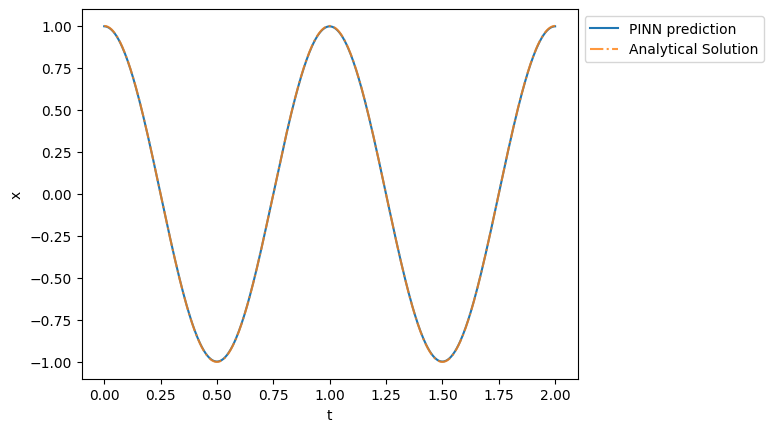

In [8]:
plt.plot(t_np, x_pred, label = 'PINN prediction')
plt.plot(t_np, x_exact,  alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### 2.b) Plot 
Plot $\mathcal{L}_r$ and $\mathcal{L}_0$ separately as functions of iteration to diagnose training.

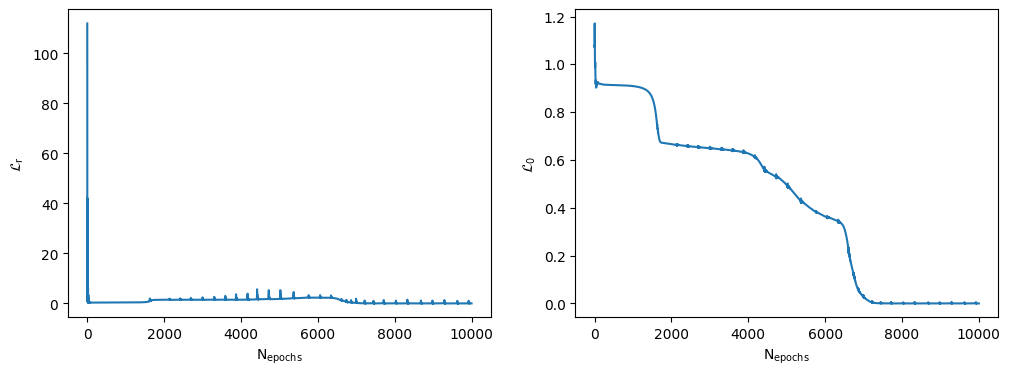

In [9]:
fig = plt.figure(figsize=(12,4))

losses = np.array(losses)
loss_r = losses[:, 1]
loss_0 = losses[:, 2]
epochs = np.arange(1, Nepochs+1)

ax = fig.add_subplot(121)
ax.plot(epochs, loss_r)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{r}$')

ax = fig.add_subplot(122)
ax.plot(epochs, loss_0)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{0}$')
plt.show()

### 4) Effect of T
Repeat with $T = 5$ (five oscillations). Observe that the PINN struggles to maintain accuracy over longer time intervals. This is the causality failure: the loss treats all times equally, so early-time accuracy is not prioritised.

In [10]:
t_break = 5.
t_test  = tf.constant(np.linspace(0, t_break, 500).reshape(-1, 1), dtype=tf.float32)
t_np = np.linspace(0, t_break, 500)
x_pred  = model(t_test).numpy().squeeze()
x_exact = np.cos(omega_true*t_np)
error = np.abs((x_pred-x_exact))
print(f'Maximum point-wise error: {np.max(error):.6f}')

Maximum point-wise error: 1.108150


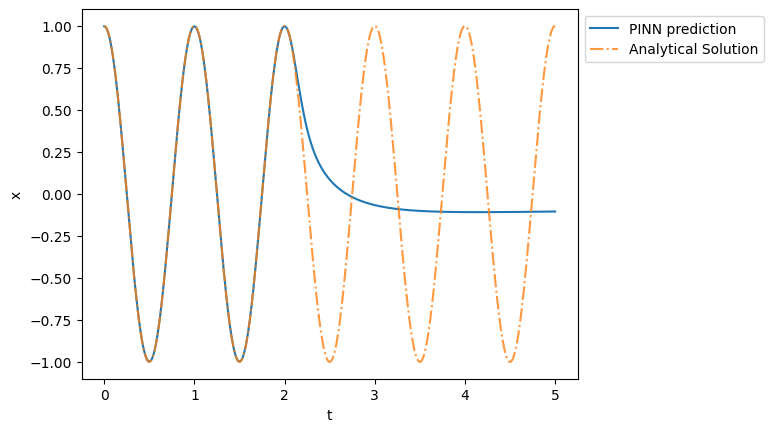

In [11]:
plt.plot(t_np, x_pred, label = 'PINN prediction')
plt.plot(t_np, x_exact,  alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### 5) Bonus — Inverse problem
Suppose $\omega$ is unknown. Add $\omega$ as a trainable scalar parameter and provide $20$ noisy measurements ${(t^d_k, x(t^d_k) + ε_k)}$ with $\epsilon_k ∼ N(0, 0.01^2)$. Add a data loss

\begin{equation}
\mathcal{L}_d = \frac{1}{20} \sum_k |\hat{x}(t^d_k) − x^d_k|^2
\end{equation}

and train. Report the recovered $\omega$ and compare to the true value $\omega = 2\pi$.

To solve this task, I developed two slightly different (but equivalent) methods.

In [12]:
omega_true = 2*np.pi
t1 = 2.
t_data = np.linspace(0, t1, 20).reshape(-1,1).astype(np.float32)
x_data = np.cos(omega_true*t_data) + np.float32(np.random.normal(0., 0.01, size = t_data.shape))

t_data = tf.constant(t_data)
x_data = tf.constant(x_data)

w_data = 100.

#### a) Model trainable variables
As a first method, I modified the added weight in the previous model (which corresponds to the $\omega$ used) in order to add it to the trainable hyperparameters. This way, the optimizer acts both on the layers weight and $\omega$ at each training step to optimize the loss. Additionally, I defined the total loss as:

\begin{equation}
 \mathcal{L} = \mathcal{L}_r + \lambda_0 \mathcal{L}_0 + \lambda_d \mathcal{L}_{d},
\end{equation}

where $\lambda_d = 100$ to ensure the convergence between the predictions and the simulated data.

In [13]:
@tf.function
def train_step(model, t, t0, trainable = False):
    """
    Tensorflow function for training step of the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float loss_pde: residual between prediction and analytical solution
    float loss_ic: residual for IC (position and velocity)
    float loss_data: residual between prediction and simulated data
    """
    with tf.GradientTape() as tape:
        loss, loss_pde, loss_ic, loss_data = loss_function(model, t, t0, trainable=trainable)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, loss_pde, loss_ic, loss_data

def train(trainable=False):
    """
    Function to train the model.

    returns:
    Sequential model: PINN model (trained)
    array (float) losses: 
        [total loss, residual between prediction and analytical solution,
         loss for ICs, residual between prediction and simulated data]
    """
    model = make_model(trainable=trainable)
    t = tf.constant(np.random.uniform(0, t1, Nr).reshape(-1, 1), dtype=tf.float32)
    t0 = tf.constant([[0.0]], dtype=tf.float32)
    losses = []
    for epoch in range(1, Nepochs + 1):
        loss, loss_pde, loss_ic, loss_data = train_step(model, t, t0, trainable=trainable)
        losses.append([float(loss), float(loss_pde), float(loss_ic), float(loss_data)])
        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | total = {loss.numpy():.3e} | "
                f"physics = {loss_pde.numpy():.3e} | IC = {loss_ic.numpy():.3e} | "
                f"data = {loss_data.numpy():.3e} | omega = {model.omega.numpy():.3f} |")

    return model, losses

In [14]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model, losses = train(trainable=True)

Initialized omega =  1.0
Epoch   500 | total = 4.978e+01 | physics = 5.452e+00 | IC = 3.419e-01 | data = 4.091e-01 | omega = 1.482 |
Epoch  1000 | total = 4.882e+01 | physics = 5.949e+00 | IC = 3.068e-01 | data = 3.980e-01 | omega = 2.249 |
Epoch  1500 | total = 4.777e+01 | physics = 7.043e+00 | IC = 2.980e-01 | data = 3.775e-01 | omega = 2.903 |
Epoch  2000 | total = 4.596e+01 | physics = 9.720e+00 | IC = 3.332e-01 | data = 3.290e-01 | omega = 3.629 |
Epoch  2500 | total = 3.320e+01 | physics = 1.288e+01 | IC = 2.716e-01 | data = 1.760e-01 | omega = 4.829 |
Epoch  3000 | total = 6.446e+00 | physics = 2.996e+00 | IC = 2.696e-02 | data = 3.181e-02 | omega = 5.808 |
Epoch  3500 | total = 4.716e-01 | physics = 2.303e-01 | IC = 1.508e-03 | data = 2.262e-03 | omega = 6.167 |
Epoch  4000 | total = 3.245e-02 | physics = 1.952e-02 | IC = 2.274e-05 | data = 1.271e-04 | omega = 6.266 |


Epoch  4500 | total = 1.645e-02 | physics = 8.538e-03 | IC = 8.805e-07 | data = 7.906e-05 | omega = 6.281 |
Epoch  5000 | total = 1.310e-02 | physics = 5.308e-03 | IC = 7.108e-07 | data = 7.781e-05 | omega = 6.282 |
Epoch  5500 | total = 1.133e-02 | physics = 3.551e-03 | IC = 6.430e-07 | data = 7.771e-05 | omega = 6.282 |
Epoch  6000 | total = 1.032e-02 | physics = 2.529e-03 | IC = 5.891e-07 | data = 7.781e-05 | omega = 6.282 |
Epoch  6500 | total = 2.887e-02 | physics = 1.878e-02 | IC = 8.388e-05 | data = 9.248e-05 | omega = 6.283 |
Epoch  7000 | total = 9.376e-03 | physics = 1.588e-03 | IC = 8.359e-07 | data = 7.780e-05 | omega = 6.283 |
Epoch  7500 | total = 8.957e-03 | physics = 1.155e-03 | IC = 6.956e-07 | data = 7.795e-05 | omega = 6.283 |
Epoch  8000 | total = 8.770e-03 | physics = 9.693e-04 | IC = 8.281e-07 | data = 7.792e-05 | omega = 6.283 |
Epoch  8500 | total = 8.654e-03 | physics = 8.640e-04 | IC = 6.278e-07 | data = 7.784e-05 | omega = 6.283 |
Epoch  9000 | total = 1.441e

Maximum point-wise error: 0.026724


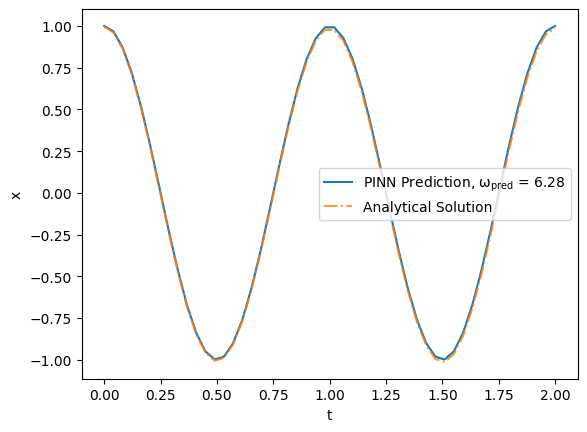

In [15]:
t_data_lin = tf.constant(np.linspace(0, t1))
x_data_lin = np.cos(omega_true*t_data_lin)
x_pred = model.predict(t_data_lin, verbose = False).squeeze()

error = np.abs((x_pred-x_data_lin))
print(f'Maximum point-wise error: {np.max(error):.6f}')

plt.plot(t_data_lin, x_data_lin, label = rf'PINN Prediction, $\rm \omega_{{pred}}$ = {model.omega.numpy():.2f}')
plt.plot(t_data_lin, x_pred, alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

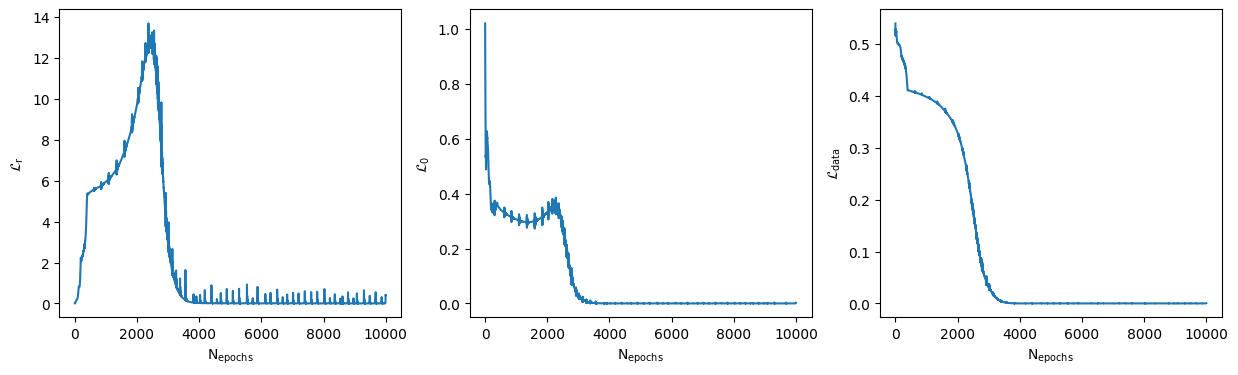

In [16]:
fig = plt.figure(figsize=(15,4))

losses = np.array(losses)
loss_r = losses[:, 1]
loss_0 = losses[:, 2]
loss_data = losses[:, 3]
epochs = np.arange(1, Nepochs+1)

ax = fig.add_subplot(131)
ax.plot(epochs, loss_r)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{r}$')

ax = fig.add_subplot(132)
ax.plot(epochs, loss_0)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{0}$')

ax = fig.add_subplot(133)
ax.plot(epochs, loss_data)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{data}$')
plt.show()

#### b) Trainable Tensorflow Variable
As a second method, I removed the added weight corresponding to $\omega$ in the previous model and defined a trainable Tensorflow variable. Even if this variable is not part of the model itself, it can still be updated by the optimizer by considering it alongside to the model trainable parameters.

Also here I defined the total loss as:

\begin{equation}
 \mathcal{L} = \mathcal{L}_r + \lambda_0 \mathcal{L}_0 + \lambda_d \mathcal{L}_{d},
\end{equation}

where $\lambda_d = 100$ to ensure the convergence between the predictions and the simulated data.

In [17]:
def make_model_omega_tf(trainable = False, hidden_layers=4, neurons=32):
    """
    Function to develop the PINN model to train.

    string trainable: determines whether omega is fixed or has to be derived from data
    float hidden_layers: number of hidden layers
    float neurons: number of neurons for each layer.

    returns: 
    Sequential model: PINN model (not trained)
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,)))
    for _ in range(hidden_layers):
        model.add(tf.keras.layers.Dense(neurons, activation="tanh"))

    model.add(tf.keras.layers.Dense(1))
    
    return model

def loss_function_omega_tf(model, t, t0, omega_tf, trainable = False):
    """"
    Function to compute the loss for the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    tf.Variable (float) omega_tf: harmonic oscillator constant to determine
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float physics_loss: residual between prediction and analytical solution
    float ic_loss: residual for IC (position and velocity)
    float ic_data: residual between prediction and simulated data
    """
    x, x_t, x_tt = second_derivative(model, t)
    res =  x_tt + omega_tf**2*x

    with tf.GradientTape() as tape:
        tape.watch(t0)
        x0 = model(t0)
    x0_t = tape.gradient(x0, t0)

    physics_loss = tf.reduce_mean(tf.square(res))
    ic_loss = tf.reduce_mean(tf.square(x0-1.))+tf.reduce_mean(tf.square(x0_t-0.))
    loss = w_pde*physics_loss+w_ic*ic_loss
    omega_loss = 0.
    if trainable == True:
        x_pred_data = model(t_data, training=True) 
        omega_loss = tf.reduce_mean(tf.square(x_pred_data - x_data))
        loss = loss + w_data*omega_loss

    return loss, physics_loss, ic_loss, omega_loss

In [18]:
@tf.function
def train_step_omega_tf(model, t, t0, omega_tf,trainable = False):
    """
    Tensorflow function for training step of the model.

    Sequential model: PINN model
    float t: time variable
    float t0: initial time
    tf.Variable (float) omega_tf: harmonic oscillator constant to determine
    string trainable: determines whether omega is fixed or has to be derived from data

    returns:
    float loss: total loss for the model
    float loss_pde: residual between prediction and analytical solution
    float loss_ic: residual for IC (position and velocity)
    float loss_data: residual between prediction and simulated data
    """
    with tf.GradientTape() as tape:
        loss, loss_pde, loss_ic, loss_data = loss_function_omega_tf(model, t, t0, omega_tf, trainable=trainable)
    grads = tape.gradient(loss, [omega_tf] + model.trainable_variables)
    optimizer.apply_gradients(zip(grads, [omega_tf] + model.trainable_variables))
    return loss, loss_pde, loss_ic, loss_data

def train_omega_tf(trainable=False):
    """
    Function to train the model.

    returns:
    Sequential model: PINN model (trained)
    array (float) losses: 
        [total loss, residual between prediction and analytical solution,
         loss for ICs, residual between prediction and simulated data]
    """
    model = make_model_omega_tf(trainable=trainable)
    t = tf.constant(np.random.uniform(0, t1, Nr).reshape(-1, 1), dtype=tf.float32)
    t0 = tf.constant([[0.0]], dtype=tf.float32)
    losses = []
    for epoch in range(1, Nepochs + 1):
        loss, loss_pde, loss_ic, loss_data = train_step_omega_tf(model, t, t0, omega_tf, trainable=trainable)
        losses.append([float(loss), float(loss_pde), float(loss_ic), float(loss_data)])
        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | total = {loss.numpy():.3e} | "
                f"physics = {loss_pde.numpy():.3e} | IC = {loss_ic.numpy():.3e} | "
                f"data = {loss_data.numpy():.3e} | omega = {omega_tf.numpy():.3f} |")

    return model, losses

In [19]:
omega_tf = tf.Variable(1., trainable=True, dtype = tf.float32)  
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model, losses = train_omega_tf(trainable=True)

Epoch   500 | total = 5.089e+01 | physics = 3.927e+00 | IC = 3.737e-01 | data = 4.322e-01 | omega = 1.317 |
Epoch  1000 | total = 4.944e+01 | physics = 5.492e+00 | IC = 3.213e-01 | data = 4.073e-01 | omega = 2.138 |
Epoch  1500 | total = 4.843e+01 | physics = 6.468e+00 | IC = 3.027e-01 | data = 3.894e-01 | omega = 2.824 |
Epoch  2000 | total = 4.704e+01 | physics = 8.841e+00 | IC = 3.326e-01 | data = 3.487e-01 | omega = 3.533 |
Epoch  2500 | total = 3.644e+01 | physics = 1.203e+01 | IC = 3.219e-01 | data = 2.119e-01 | omega = 4.721 |
Epoch  3000 | total = 8.895e+00 | physics = 4.006e+00 | IC = 3.897e-02 | data = 4.499e-02 | omega = 5.750 |
Epoch  3500 | total = 1.388e+00 | physics = 6.754e-01 | IC = 2.777e-03 | data = 6.852e-03 | omega = 6.116 |
Epoch  4000 | total = 1.608e-01 | physics = 1.163e-01 | IC = 1.601e-04 | data = 4.282e-04 | omega = 6.244 |
Epoch  4500 | total = 3.550e-02 | physics = 2.654e-02 | IC = 6.796e-06 | data = 8.898e-05 | omega = 6.277 |
Epoch  5000 | total = 2.613e

Maximum point-wise error: 0.003763


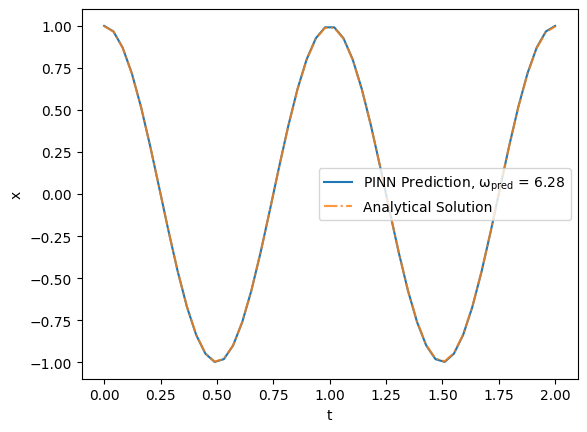

In [20]:
t_data_lin = tf.constant(np.linspace(0, t1))
x_data_lin = np.cos(omega_true*t_data_lin)
x_pred = model.predict(t_data_lin, verbose = False).squeeze()

error = np.abs((x_pred-x_data_lin))
print(f'Maximum point-wise error: {np.max(error):.6f}')

plt.plot(t_data_lin, x_data_lin, label = rf'PINN Prediction, $\rm \omega_{{pred}}$ = {omega_tf.numpy():.2f}')
plt.plot(t_data_lin, x_pred, alpha = 0.8, linestyle = '-.', label = 'Analytical Solution')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

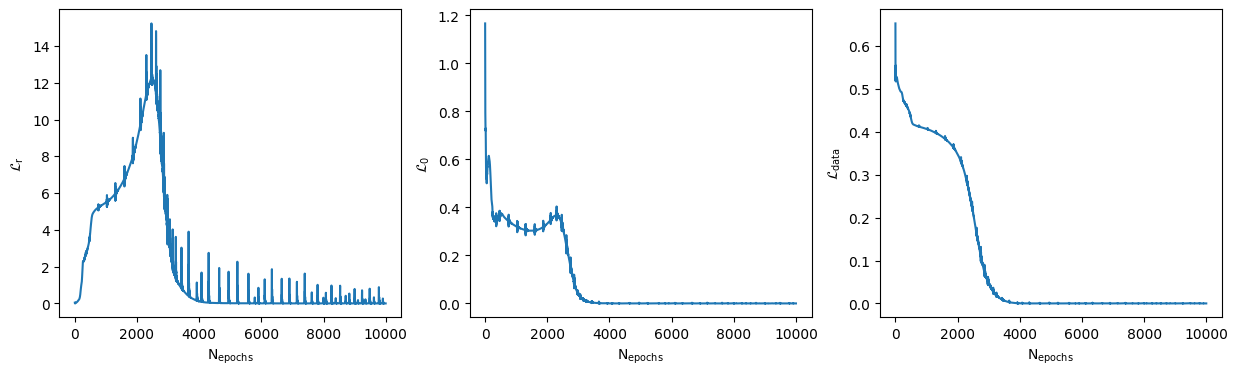

In [21]:
fig = plt.figure(figsize=(15,4))

losses = np.array(losses)
loss_r = losses[:, 1]
loss_0 = losses[:, 2]
loss_data = losses[:, 3]
epochs = np.arange(1, Nepochs+1)

ax = fig.add_subplot(131)
ax.plot(epochs, loss_r)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{r}$')

ax = fig.add_subplot(132)
ax.plot(epochs, loss_0)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{0}$')

ax = fig.add_subplot(133)
ax.plot(epochs, loss_data)
ax.set_xlabel(r'$\rm N_{epochs}$')
ax.set_ylabel(r'$\rm \mathcal{L}_{data}$')
plt.show()